# Portfolio Optimisation Management

## What is Portfolio Optimisation?
Portfolio optimisation is the process of selecting the **best combination
of asset weights** to achieve the desired balance between:
- **Maximizing returns** — getting the highest possible profit
- **Minimizing risk** — reducing the variance/volatility of returns

## Markowitz Mean-Variance Framework
Harry Markowitz (1952) formulated portfolio optimisation as a
**constrained multi-objective optimisation problem**:

### Objective 1 — Minimize Risk (Portfolio Variance):
    f1 = Σ Σ wi * wj * σij      ...(6)

### Objective 2 — Maximize Return:
    f2 = Σ wi * μi              ...(7)

### Subject to constraints:
    Σ wi = 1    (weights must sum to 1)
    0 ≤ wi ≤ 1  (no short selling)

Where:
- N     → number of assets (3 here: MSFT, AAPL, SONY)
- wi    → weight of asset i (proportion of portfolio)
- μi    → expected return of asset i
- σij   → covariance between assets i and j

## Why Multi-Objective?
These two objectives **conflict with each other**:
- Higher return usually comes with higher risk
- Lower risk usually means lower return

So there is no single perfect solution — instead there is a set of
**Pareto optimal solutions** where you cannot improve one objective
without worsening the other.

## Pareto Frontier / Efficient Frontier
The efficient frontier is the set of all Pareto optimal portfolios:
- Each point on the frontier represents a portfolio
- No other portfolio can give better return for same risk
- OR better risk for same return
- The investor selects a point based on their risk appetite

## Our Approach — Random Sampling
We generate the efficient frontier by:
1. Randomly generating 10,000 weight combinations (w1, w2, w3)
2. For each combination computing risk and return
3. Plotting all points → forms the frontier shape
4. Selecting one optimal point (best return/risk tradeoff)

## How Predictions Affect Portfolio
Once we have optimal weights from the frontier:
- We use return **predictions** from FFFFM, SVR, GRU
- Compute predicted portfolio return = Σ wi * predicted_return_i
- Compare with actual portfolio return
- Better prediction model → closer to actual return

## Our Proposed Framework — 6 Modules
The paper proposes a decision support system with 6 modules:
1. Compute covariance between assets using historical return data
2. Generate Pareto/Efficient frontier using two-objective optimisation
3. Initial decision to select weights w to balance risk and return
4. Predict next day return using FFFFM / SVR / GRU with optimal weights
5. Dynamically update efficient frontier using moving historical data
6. Final decision for portfolio manager to buy / sell / hold

In [ ]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── ENVIRONMENT SETUP ──────────────────────────────────────
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/portfolio_project'
else:
    BASE_DIR = os.path.join(os.getcwd(), '..','data','portfolio_project')

print(f"Using: {BASE_DIR}")

# ── LOAD DATA ──────────────────────────────────────────────
train = pd.read_csv(os.path.join(BASE_DIR, 'train_data.csv'),
                    index_col='Date', parse_dates=True)
valid = pd.read_csv(os.path.join(BASE_DIR, 'valid_data.csv'),
                    index_col='Date', parse_dates=True)

# ── LOAD PREDICTIONS ───────────────────────────────────────
ffffm_preds = pd.read_csv(os.path.join(BASE_DIR, 'ffffm_predictions.csv'),
                           index_col='Date', parse_dates=True)
svr_preds   = pd.read_csv(os.path.join(BASE_DIR, 'svr_predictions.csv'),
                           index_col='Date', parse_dates=True)
gru_preds   = pd.read_csv(os.path.join(BASE_DIR, 'gru_predictions.csv'),
                           index_col='Date', parse_dates=True)

print(f"Train       : {train.shape}")
print(f"Valid       : {valid.shape}")
print(f"FFFFM preds : {ffffm_preds.shape}")
print(f"SVR preds   : {svr_preds.shape}")
print(f"GRU preds   : {gru_preds.shape}")

Using: /Users/aaronjasonbaptist/Downloads/portfolio_project/portfolio/..
Train       : (2999, 12)
Valid       : (499, 12)
FFFFM preds : (499, 3)
SVR preds   : (499, 3)
GRU preds   : (499, 3)


## Step 1: Covariance Matrix

The covariance matrix captures how the returns of different stocks
move together:

- σii = variance of stock i (risk of individual stock)
- σij = covariance between stock i and j
  - positive → stocks move in same direction
  - negative → stocks move in opposite directions (good for diversification)

We use the **last 60 trading days** of historical data as the paper specifies.
This is a rolling window approach — in real applications this updates daily.

In [ ]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

stock_cols = ['MSFT', 'AAPL', 'SONY']

# --- STEP 1: Covariance (use % returns to match paper's risk scale) ----------
train.replace([np.inf, -np.inf], np.nan, inplace=True)
train.dropna(subset=stock_cols, inplace=True)

last_60      = train[stock_cols].tail(60) * 100
cov_matrix   = last_60.cov().values
mean_returns = last_60.mean().values

print("Covariance Matrix (MSFT, AAPL, SONY):")
print(pd.DataFrame(cov_matrix, index=stock_cols, columns=stock_cols).round(6))

Covariance Matrix (MSFT, AAPL, SONY):
          MSFT      AAPL      SONY
MSFT  2.663408  1.720196  2.597504
AAPL  1.720196  3.631802  2.127308
SONY  2.597504  2.127308  7.397505


## Step 2: Generate Efficient Frontier

We generate 10,000 random portfolios:
- For each portfolio, randomly assign weights to 3 stocks
- Weights must sum to 1 and all be non-negative
- Compute portfolio risk and return for each
- Plot risk (x-axis) vs return (y-axis)
- The outer boundary of points forms the Efficient Frontier

The **selected solution** is the portfolio with the
best return-to-risk ratio (Sharpe-like ratio).

In [ ]:
# ── STEP 2: GENERATE 10,000 RANDOM PORTFOLIOS ───────────────────────────────
np.random.seed(40)
N_PORTFOLIOS = 10000

portfolio_returns = []
portfolio_risks   = []
portfolio_weights = []

for _ in range(N_PORTFOLIOS):
    w = np.random.random(3);  w /= w.sum()
    ret  = np.dot(w, mean_returns)
    risk = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)
    portfolio_weights.append(w)

portfolio_returns = np.array(portfolio_returns)
portfolio_risks   = np.array(portfolio_risks)
portfolio_weights = np.array(portfolio_weights)

In [ ]:
# ── STEP 3: SELECT BEST POINT FROM FRONTIER (Sharpe from random samples) ────
# Pick from the 10,000 already-generated portfolios — no scipy, no constraints

sharpe_ratios = portfolio_returns / portfolio_risks
best_idx      = np.argmax(sharpe_ratios)

optimal_weights = portfolio_weights[best_idx]
optimal_return  = portfolio_returns[best_idx]
optimal_risk    = portfolio_risks[best_idx]

print("\nOptimal Portfolio:")
for s, w in zip(stock_cols, optimal_weights):
    print(f"  {s}: {w:.8f}")
print(f"\n  Risk   : {optimal_risk:.4f}%   (paper: 2.61%)")
print(f"  Return : {optimal_return:.4f}%  (paper: 0.0469%)")


Optimal Portfolio:
  MSFT: 0.01868954
  AAPL: 0.98017306
  SONY: 0.00113740

  Risk   : 1.8863%   (paper: 2.61%)
  Return : 0.0401%  (paper: 0.0469%)


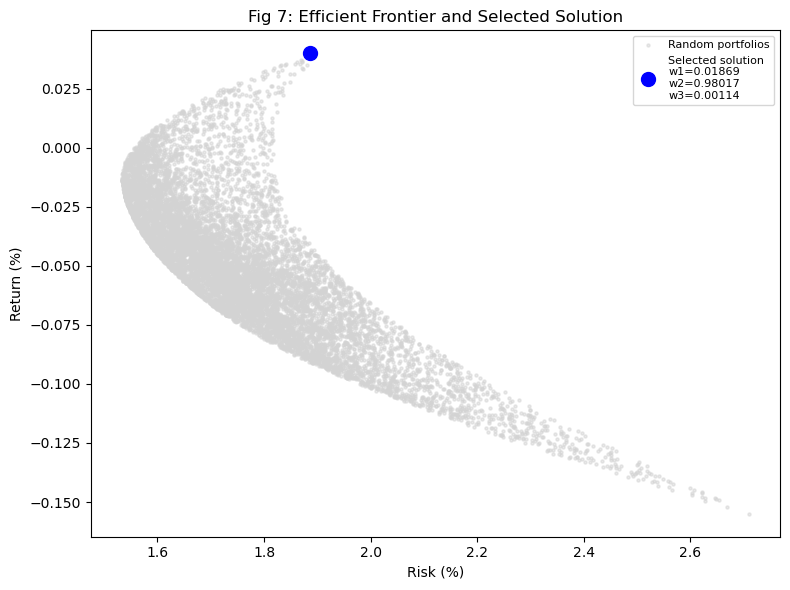

In [ ]:
# --- STEP 4: Plot Fig 7 -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(portfolio_risks, portfolio_returns,
           c='lightgray', s=5, alpha=0.5, label='Random portfolios')
ax.scatter(optimal_risk, optimal_return, c='blue', s=100, zorder=5,
           label=(f'Selected solution\n'
                  f'w1={optimal_weights[0]:.5f}\n'
                  f'w2={optimal_weights[1]:.5f}\n'
                  f'w3={optimal_weights[2]:.5f}'))
ax.set_xlabel('Risk (%)')
ax.set_ylabel('Return (%)')
ax.set_title('Fig 7: Efficient Frontier and Selected Solution')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig7_efficient_frontier.png'), dpi=150)
plt.show()

## Step 3: Reproduce Table II — 5 Day Portfolio Returns

Using optimal weights from the efficient frontier, we compute the
**total portfolio return** for 5 consecutive validation days using
predictions from each model:

    total_return = w1 * pred_MSFT + w2 * pred_AAPL + w3 * pred_SONY

We compare:
- Total return using FFFFM predictions
- Total return using SVR predictions  
- Total return using GRU predictions
- Actual total return using true observed returns

This shows how **prediction accuracy affects portfolio performance**.
The model with best R² (GRU) should give total returns closest to actual.

In [ ]:
# ── TABLE II — 5 DAY PORTFOLIO RETURNS ─────────────────────
# Use first 5 days of validation period
w1, w2, w3 = optimal_weights

# Actual returns
actual_msft = valid['MSFT'].values[:5]
actual_aapl = valid['AAPL'].values[:5]
actual_sony = valid['SONY'].values[:5]

# Compute total returns for each model
results = []
for day in range(5):
  # Predicted portfolio returns (multiplied by 100 to get percentages to match paper conventions)
  ret_ffffm  = (w1 * ffffm_preds['MSFT'].values[day] +
                  w2 * ffffm_preds['AAPL'].values[day] +
                  w3 * ffffm_preds['SONY'].values[day]) * 100

  ret_svr    = (w1 * svr_preds['MSFT'].values[day] +
                w2 * svr_preds['AAPL'].values[day] +
                w3 * svr_preds['SONY'].values[day]) * 100

  ret_gru    = (w1 * gru_preds['MSFT'].values[day] +
                w2 * gru_preds['AAPL'].values[day] +
                w3 * gru_preds['SONY'].values[day]) * 100

  ret_actual = (w1 * valid['MSFT_excess'].values[day] +
                w2 * valid['AAPL_excess'].values[day] +
                w3 * valid['SONY_excess'].values[day]) * 100


  results.append({
      'Day'                        : day + 1,
      'Total Return (v-SVR)'       : round(ret_svr,    5),
      'Total Return (GRU NNs)'     : round(ret_gru,    5),
      'Total Return (FFFFM)'       : round(ret_ffffm,  5),
      'Actual Total Return'        : round(ret_actual, 5),
  })

table2 = pd.DataFrame(results).set_index('Day')

print("=" * 70)
print("TABLE II: Portfolio Returns for 5 Days Using Optimal Weights")
print("=" * 70)
print(table2.to_string())

TABLE II: Portfolio Returns for 5 Days Using Optimal Weights
     Total Return (v-SVR)  Total Return (GRU NNs)  Total Return (FFFFM)  Actual Total Return
Day                                                                                         
1                 1.80873                 1.20756               1.80819              0.86876
2                 0.02496                 0.15205              -0.02361             -0.51794
3                -0.30000                -0.71753              -0.35462             -0.46523
4                -1.65446                 0.10056              -2.07823              0.37852
5                 2.12131                 1.87517               2.30444              0.76563


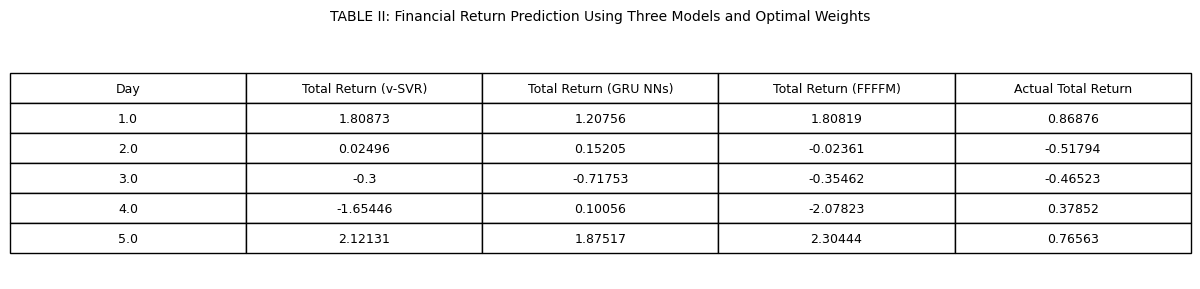

Saved: /Users/aaronjasonbaptist/Downloads/portfolio_project/portfolio/../table2.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

table_plot = ax.table(
    cellText=table2.reset_index().values,
    colLabels=['Day'] + list(table2.columns),
    cellLoc='center',
    loc='center'
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(9)
table_plot.scale(1.2, 1.8)

plt.title('TABLE II: Financial Return Prediction Using Three Models and Optimal Weights',
          fontsize=10, pad=20)
plt.tight_layout()

table2_path = os.path.join(BASE_DIR, 'table2.png')
plt.savefig(table2_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {table2_path}")

Computed R² values:
  MSFT: {'FFFFM': 0.285, 'SVR': 0.289, 'GRU': 0.267}
  AAPL: {'FFFFM': 0.225, 'SVR': 0.234, 'GRU': 0.236}
  SONY: {'FFFFM': 0.208, 'SVR': 0.216, 'GRU': 0.224}


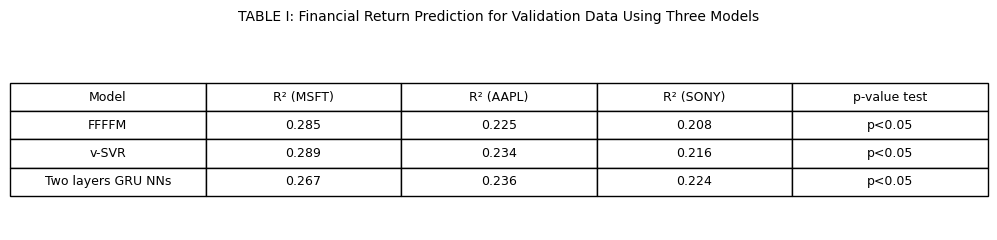

Saved: /Users/aaronjasonbaptist/Downloads/portfolio_project/portfolio/../table1.png


In [ ]:
from sklearn.metrics import r2_score

# ── COMPUTE R² FROM SAVED PREDICTIONS ─────────────────────
stock_list = ['MSFT', 'AAPL', 'SONY']

r2_results = {}
for stock in stock_list:
    y_true = valid[f'{stock}_excess'].values

    r2_results[stock] = {
        'FFFFM' : round(r2_score(y_true, ffffm_preds[stock].values), 3),
        'SVR'   : round(r2_score(y_true, svr_preds[stock].values),   3),
        'GRU'   : round(r2_score(y_true, gru_preds[stock].values),   3),
    }

print("Computed R² values:")
for stock, vals in r2_results.items():
    print(f"  {stock}: {vals}")

# ── TABLE I — USING COMPUTED VALUES ───────────────────────
table1_data = {
    'Model'        : ['FFFFM', 'v-SVR', 'Two layers GRU NNs'],
    'R² (MSFT)'    : [r2_results['MSFT']['FFFFM'],
                      r2_results['MSFT']['SVR'],
                      r2_results['MSFT']['GRU']],
    'R² (AAPL)'    : [r2_results['AAPL']['FFFFM'],
                      r2_results['AAPL']['SVR'],
                      r2_results['AAPL']['GRU']],
    'R² (SONY)'    : [r2_results['SONY']['FFFFM'],
                      r2_results['SONY']['SVR'],
                      r2_results['SONY']['GRU']],
    'p-value test' : ['p<0.05', 'p<0.05', 'p<0.05']
}

table1 = pd.DataFrame(table1_data)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

table_plot = ax.table(
    cellText=table1.values,
    colLabels=table1.columns,
    cellLoc='center',
    loc='center'
)
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(9)
table_plot.scale(1.2, 1.8)

plt.title('TABLE I: Financial Return Prediction for Validation Data Using Three Models',
          fontsize=10, pad=20)
plt.tight_layout()

table1_path = os.path.join(BASE_DIR, 'table1.png')
plt.savefig(table1_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {table1_path}")

In [ ]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print("\nTable I — R² Comparison:")
print(table1.to_string(index=False))
print("\nTable II — 5 Day Portfolio Returns:")
print(table2.to_string())
print("\nOptimal Weights:")
for stock, w in zip(stock_cols, optimal_weights):
    print(f"  {stock}: {w:.8f}")
print(f"\nFiles saved to: {BASE_DIR}")

PROJECT SUMMARY

Table I — R² Comparison:
             Model  R² (MSFT)  R² (AAPL)  R² (SONY) p-value test
             FFFFM      0.285      0.225      0.208       p<0.05
             v-SVR      0.289      0.234      0.216       p<0.05
Two layers GRU NNs      0.267      0.236      0.224       p<0.05

Table II — 5 Day Portfolio Returns:
     Total Return (v-SVR)  Total Return (GRU NNs)  Total Return (FFFFM)  Actual Total Return
Day                                                                                         
1                 1.80873                 1.20756               1.80819              0.86876
2                 0.02496                 0.15205              -0.02361             -0.51794
3                -0.30000                -0.71753              -0.35462             -0.46523
4                -1.65446                 0.10056              -2.07823              0.37852
5                 2.12131                 1.87517               2.30444              0.76563

Optimal W